# System Capacity & Care Load Analytics for Unaccompanied Children



## Organization
U.S. Department of Health & Human Services (HHS)

## Objective
Analyze capacity, care load, intake trends, strain periods, and forecast future healthcare demand using Exploratory Data Analysis (EDA), Statistical Analysis, and Time Series Forecasting.

---

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Prophet
- Google Colab
- Google Drive
- Streamlit

---

## Dataset

Source:
U.S. Department of Health & Human Services

Duration:
2023–2025
---

## Author

Bandham Raju

# Table of Contents

1. Import Libraries
2. Load Dataset
3. Data Cleaning
4. Data Understanding
5. Descriptive Statistics
6. KPI Analysis
7. Trend Analysis
8. Comparative Analysis
9. Rolling Statistics
10. Variability Analysis
11. Strain Detection
12. Forecasting
13. Export Results
14. Conclusion

### Importing necessary libraries

In [1]:
import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from prophet import Prophet

warnings.filterwarnings("ignore")

### project paths

In [2]:
PROJECT_NAME = "System Capacity & Care Load Analytics for Unaccompanied Children"

# Folders
DATA_DIR = "Data"
GRAPH_DIR = "Graphs"
OUTPUT_DIR = "Outputs"
MODEL_DIR = "Models"
REPORT_DIR = "Reports"

# Dataset Paths
RAW_CSV = os.path.join(
    DATA_DIR,
    "HHS_Unaccompanied_Alien_Children_Program.csv"
)

CLEANED_CSV = os.path.join(
    DATA_DIR,
    "Cleaned_HHS_Unaccompanied_Alien_Children_Program.csv"
)

### creating folders

In [3]:
folders = [
    DATA_DIR,
    GRAPH_DIR,
    OUTPUT_DIR,
    MODEL_DIR,
    REPORT_DIR
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders are ready.")

Folders are ready.


### saving graphs path

In [4]:
def save_plot(folder, filename):

    save_dir = os.path.join(GRAPH_DIR, folder)

    os.makedirs(save_dir, exist_ok=True)

    filepath = os.path.join(save_dir, filename)

    plt.savefig(
        filepath,
        dpi=300,
        bbox_inches="tight"
    )

    print("Saved:", filepath)

# Data loading  And Inspecting

### Checking dataset available

In [5]:
print("Dataset path:")
print(RAW_CSV)

print()

print("Dataset exists:")
print(os.path.exists(RAW_CSV))

Dataset path:
Data\HHS_Unaccompanied_Alien_Children_Program.csv

Dataset exists:
True


### Load dataset

In [6]:
df = pd.read_csv(RAW_CSV)

print("Dataset loaded successfully.")

Dataset loaded successfully.


### Basic inspection

In [7]:
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


### Dataset dimensions

In [8]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1170
Columns: 6


### Column names

In [9]:
df.columns

Index(['Date', 'Children apprehended and placed in CBP custody*',
       'Children in CBP custody', 'Children transferred out of CBP custody',
       'Children in HHS Care', 'Children discharged from HHS Care'],
      dtype='str')

### Data types

In [10]:
df.dtypes

Date                                                   str
Children apprehended and placed in CBP custody*    float64
Children in CBP custody                            float64
Children transferred out of CBP custody            float64
Children in HHS Care                                   str
Children discharged from HHS Care                  float64
dtype: object

### Dataset information

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             720 non-null    str    
 1   Children apprehended and placed in CBP custody*  720 non-null    float64
 2   Children in CBP custody                          720 non-null    float64
 3   Children transferred out of CBP custody          720 non-null    float64
 4   Children in HHS Care                             720 non-null    str    
 5   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(4), str(2)
memory usage: 69.5 KB


###  Finding No.of Missing values

In [12]:

print('Missing Values:',df.isnull().sum())

Missing Values: Date                                               450
Children apprehended and placed in CBP custody*    450
Children in CBP custody                            450
Children transferred out of CBP custody            450
Children in HHS Care                               450
Children discharged from HHS Care                  450
dtype: int64


In [13]:
df.tail()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
1165,NaN,NaN,NaN,NaN,NaN,NaN
1166,NaN,NaN,NaN,NaN,NaN,NaN
1167,NaN,NaN,NaN,NaN,NaN,NaN
1168,NaN,NaN,NaN,NaN,NaN,NaN
1169,NaN,NaN,NaN,NaN,NaN,NaN


### Random observations selected from the dataset.

In [14]:

df.sample(10)

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
204,"February 19, 2025",12.0,17.0,17.0,"2,528",19.0
255,"December 08, 2024",132.0,243.0,183.0,"6,286",172.0
1126,NaN,NaN,NaN,NaN,NaN,NaN
114,"July 07, 2025",3.0,18.0,8.0,"2,317",20.0
796,NaN,NaN,NaN,NaN,NaN,NaN
525,"November 06, 2023",123.0,233.0,159.0,"9,286",316.0
1090,NaN,NaN,NaN,NaN,NaN,NaN
742,NaN,NaN,NaN,NaN,NaN,NaN
672,"April 03, 2023",118.0,139.0,168.0,"8,054",284.0
976,NaN,NaN,NaN,NaN,NaN,NaN


### Finding Unique values

In [15]:
df.nunique()

Date                                               720
Children apprehended and placed in CBP custody*    169
Children in CBP custody                            216
Children transferred out of CBP custody            185
Children in HHS Care                               642
Children discharged from HHS Care                  285
dtype: int64

#  Data Cleaning & Preparation

This section ensures the dataset is complete, accurate, and ready for analysis by handling missing values, formatting dates, checking duplicates, and validating data quality.


### Remove Empty Rows

In [16]:
print('Before:',df.shape)
df = df.dropna(how='all')
print('After Removing Empty Rows-shape:',df.shape)

Before: (1170, 6)
After Removing Empty Rows-shape: (720, 6)


### Check Date Range

In [17]:
print("First 5 Dates")
print(df["Date"].head())

print("\nLast 5 Dates")
print(df["Date"].tail())

First 5 Dates
0    December 21, 2025
1    December 18, 2025
2    December 17, 2025
3    December 16, 2025
4    December 15, 2025
Name: Date, dtype: str

Last 5 Dates
715    January 25, 2023
716    January 24, 2023
717    January 23, 2023
718    January 22, 2023
719    January 12, 2023
Name: Date, dtype: str


### Clean the Date Column

In [18]:
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

print("Date Type:", df["Date"].dtype)
print("Earliest Date:", df["Date"].min())
print("Latest Date:", df["Date"].max())

Date Type: datetime64[us]
Earliest Date: 2023-01-12 00:00:00
Latest Date: 2025-12-21 00:00:00


### Sort the dataset

In [19]:
df = df.sort_values("Date")
df = df.reset_index(drop=True)

### Check for invalid dates

In [20]:
print("Missing Dates:", df["Date"].isna().sum())

Missing Dates: 0


### Check HHS Care Column

In [21]:
print(df["Children in HHS Care"].head())

print(df["Children in HHS Care"].dtype)

print(df["Children in HHS Care"].describe())

0    6,566
1    7,122
2    7,280
3    7,433
4    7,538
Name: Children in HHS Care, dtype: str
str
count       720
unique      642
top       7,546
freq          3
Name: Children in HHS Care, dtype: object


### Check for missing values in HHS Care

In [22]:
print(df["Children in HHS Care"].isna().sum())

0


### Ensure it's numeric

In [23]:
df["Children in HHS Care"] = (
    df["Children in HHS Care"]
        .astype(str)
        .str.replace(",", "", regex=False)
)

df["Children in HHS Care"] = pd.to_numeric(
    df["Children in HHS Care"],
    errors="coerce"
)

In [24]:
df['Children in HHS Care'].head(10)

0    6566
1    7122
2    7280
3    7433
4    7538
5    7472
6    7743
7    7803
8    7903
9    7879
Name: Children in HHS Care, dtype: int64

### clean all numeric columns before converting.

In [25]:
numeric_cols = [
    "Children apprehended and placed in CBP custody*",
    "Children in CBP custody",
    "Children transferred out of CBP custody",
    "Children in HHS Care",
    "Children discharged from HHS Care"
]

for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
    )

    df[col] = pd.to_numeric(df[col], errors="coerce")

In [26]:
df

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,2023-01-12,33.0,53.0,34.0,6566,436.0
1,2023-01-22,32.0,49.0,39.0,7122,227.0
2,2023-01-23,32.0,50.0,39.0,7280,181.0
3,2023-01-24,47.0,42.0,47.0,7433,175.0
4,2023-01-25,20.0,22.0,41.0,7538,180.0
...,...,...,...,...,...,...
715,2025-12-15,11.0,42.0,9.0,2470,7.0
716,2025-12-16,8.0,54.0,15.0,2468,9.0
717,2025-12-17,7.0,31.0,11.0,2481,10.0
718,2025-12-18,11.0,50.0,6.0,2472,16.0


In [27]:
print(df['Children in HHS Care'].dtype)
df['Children in HHS Care'].head()

int64


0    6566
1    7122
2    7280
3    7433
4    7538
Name: Children in HHS Care, dtype: int64

In [28]:
df.dtypes

Date                                               datetime64[us]
Children apprehended and placed in CBP custody*           float64
Children in CBP custody                                   float64
Children transferred out of CBP custody                   float64
Children in HHS Care                                        int64
Children discharged from HHS Care                         float64
dtype: object

### Date Range

In [29]:
print('Earliest Date:',df['Date'].min())
print('Latest Date:',df['Date'].max())

Earliest Date: 2023-01-12 00:00:00
Latest Date: 2025-12-21 00:00:00


### Check Missing Dates

In [30]:
# Create complete date range
full_dates = pd.date_range(
    start=df["Date"].min(),
    end=df["Date"].max(),
    freq="D"
)

# Find missing dates
missing_dates = full_dates.difference(df["Date"])

print("Total Missing Dates:", len(missing_dates))
missing_dates[:20]

Total Missing Dates: 355


DatetimeIndex(['2023-01-13', '2023-01-14', '2023-01-15', '2023-01-16',
               '2023-01-17', '2023-01-18', '2023-01-19', '2023-01-20',
               '2023-01-21', '2023-01-26', '2023-01-27', '2023-01-28',
               '2023-02-03', '2023-02-04', '2023-02-10', '2023-02-11',
               '2023-02-17', '2023-02-18', '2023-02-19', '2023-02-24'],
              dtype='datetime64[us]', freq=None)

### check missing values again

In [31]:
print(df.isnull().sum())

Date                                               0
Children apprehended and placed in CBP custody*    0
Children in CBP custody                            0
Children transferred out of CBP custody            0
Children in HHS Care                               0
Children discharged from HHS Care                  0
dtype: int64


### check duplicate rows

In [32]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


### Verify final shape 

In [33]:
print("Final Shape:", df.shape)

Final Shape: (720, 6)


In [34]:
# Basic Stats of Data
df.describe()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
count,720,720.000000,720.000000,720.000000,720.000000,720.000000
mean,2024-07-06 05:30:00,93.523611,171.494444,128.668056,6061.275000,173.406944
min,2023-01-12 00:00:00,0.000000,7.000000,0.000000,1972.000000,0.000000
25%,2023-10-16 18:00:00,12.000000,36.000000,14.000000,2467.750000,19.750000
50%,2024-07-05 12:00:00,99.000000,193.000000,157.000000,6406.500000,181.000000
75%,2025-03-25 06:00:00,147.250000,263.250000,199.250000,8010.250000,267.000000
max,2025-12-21 00:00:00,333.000000,531.000000,440.000000,11516.000000,505.000000
std,NaN,72.646625,126.354965,97.322012,2833.070109,125.702841


### duplicate dates

In [35]:
duplicate_dates = df["Date"].duplicated().sum()

print("Duplicate Dates:", duplicate_dates)

Duplicate Dates: 0


### Invalid Transfer Records

A child transferred out of CBP custody cannot logically exceed the number of children currently in CBP custody (at least as a simple validation rule).

In [36]:
invalid_transfers = df[
    df["Children transferred out of CBP custody"] >
    df["Children in CBP custody"]
]

print("Invalid Transfer Records:", len(invalid_transfers))

invalid_transfers.head(10)

Invalid Transfer Records: 86


,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
3,2023-01-24,47.0,42.0,47.0,7433,175.0
4,2023-01-25,20.0,22.0,41.0,7538,180.0
9,2023-02-02,15.0,13.0,23.0,7879,298.0
22,2023-02-22,107.0,215.0,230.0,7978,232.0
23,2023-02-23,101.0,162.0,178.0,7914,386.0
27,2023-03-01,84.0,158.0,193.0,7930,307.0
47,2023-04-03,118.0,139.0,168.0,8054,284.0
63,2023-04-25,81.0,230.0,242.0,8017,202.0
70,2023-05-04,153.0,253.0,286.0,8790,332.0
79,2023-05-17,57.0,162.0,193.0,8569,307.0


### Invalid Discharge Records

In [37]:
invalid_discharges = df[
    df["Children discharged from HHS Care"] >
    df["Children in HHS Care"]
]

print("Invalid Discharge Records:", len(invalid_discharges))

invalid_discharges.head(10)

Invalid Discharge Records: 0


,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care


#  Feature Engineering

In [38]:
df["Total System Load"] = (
    df["Children in CBP custody"] +
    df["Children in HHS Care"]
)

df[["Date", "Total System Load"]].head()

,Date,Total System Load
0,2023-01-12,6619.0
1,2023-01-22,7171.0
2,2023-01-23,7330.0
3,2023-01-24,7475.0
4,2023-01-25,7560.0


In [39]:
print(df["Total System Load"].isna().sum())

0


In [40]:
df["Total System Load"].describe()

count      720.000000
mean      6232.769444
std       2918.458078
min       2002.000000
25%       2500.750000
50%       6633.500000
75%       8249.500000
max      11762.000000
Name: Total System Load, dtype: float64

In [41]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,720,2024-07-06 05:30:00,2023-01-12 00:00:00,2023-10-16 18:00:00,2024-07-05 12:00:00,2025-03-25 06:00:00,2025-12-21 00:00:00,NaN
Children apprehended and placed in CBP custody*,720.0,93.523611,0.0,12.0,99.0,147.25,333.0,72.646625
Children in CBP custody,720.0,171.494444,7.0,36.0,193.0,263.25,531.0,126.354965
Children transferred out of CBP custody,720.0,128.668056,0.0,14.0,157.0,199.25,440.0,97.322012
Children in HHS Care,720.0,6061.275,1972.0,2467.75,6406.5,8010.25,11516.0,2833.070109
Children discharged from HHS Care,720.0,173.406944,0.0,19.75,181.0,267.0,505.0,125.702841
Total System Load,720.0,6232.769444,2002.0,2500.75,6633.5,8249.5,11762.0,2918.458078


--------------------------------------------------------------------------

# KPI Analysis

This section computes the five key performance indicators (KPIs) required to evaluate system capacity, intake pressure, care load stability, operational backlog, and discharge performance within the Unaccompanied Children care system. Together, these KPIs provide a comprehensive assessment of healthcare system efficiency and support data-driven decision-making.

## KPI 1-  Total Children Under Care

Measures the total number of children currently under the responsibility of the care system.

In [42]:
df["Total Children Under Care"] = (
    df["Children in CBP custody"]
    + df["Children in HHS Care"]
)

df[["Date", "Total Children Under Care"]].head()

,Date,Total Children Under Care
0,2023-01-12,6619.0
1,2023-01-22,7171.0
2,2023-01-23,7330.0
3,2023-01-24,7475.0
4,2023-01-25,7560.0


In [43]:
df["Total Children Under Care"].describe()

count      720.000000
mean      6232.769444
std       2918.458078
min       2002.000000
25%       2500.750000
50%       6633.500000
75%       8249.500000
max      11762.000000
Name: Total Children Under Care, dtype: float64

### Interpretation

The average number of children under care is 6,233 per day, with values ranging from 2,002 to 11,762. This indicates that the system experienced substantial fluctuations in overall care demand during the study period.

## KPI 2 — Net Intake Pressure

Measures whether more children are entering or leaving the care system each day.

In [44]:
df["Net Intake Pressure"] = (
    df["Children transferred out of CBP custody"]
    - df["Children discharged from HHS Care"]
)

df[["Date", "Net Intake Pressure"]].head()

,Date,Net Intake Pressure
0,2023-01-12,-402.0
1,2023-01-22,-188.0
2,2023-01-23,-142.0
3,2023-01-24,-128.0
4,2023-01-25,-139.0


In [45]:
df["Net Intake Pressure"].describe()

count    720.000000
mean     -44.738889
std       95.863856
min     -465.000000
25%      -94.250000
50%      -11.500000
75%        5.250000
max      206.000000
Name: Net Intake Pressure, dtype: float64

###  Interpretation

The average net intake pressure is −44.74, indicating that, on most days, more children were discharged than transferred into HHS care. This suggests a gradual reduction in the overall care load over time.

## KPI 3 — Care Load Volatility Index

Measures the daily variation in the overall number of children receiving care.

In [46]:
df["Care Load Volatility Index"] = (
    df["Total Children Under Care"]
      .pct_change()
      .abs()
      .fillna(0)
) * 100
df[["Date","Care Load Volatility Index"]].head()

,Date,Care Load Volatility Index
0,2023-01-12,0.000000
1,2023-01-22,8.339628
2,2023-01-23,2.217264
3,2023-01-24,1.978172
4,2023-01-25,1.137124


In [47]:
df["Care Load Volatility Index"].describe()

count    720.000000
mean       1.244138
std        1.432312
min        0.000000
25%        0.386718
50%        0.821762
75%        1.586401
max       11.601513
Name: Care Load Volatility Index, dtype: float64

### Interpretation

The average daily change in the care load is 1.25%, indicating that the total number of children under care remained relatively stable, with only occasional periods of higher fluctuation.

## KPI 4 — Backlog Accumulation Rate

Measures the proportion of children still waiting in CBP custody.

In [48]:
df["Backlog Accumulation Rate"] = (
    df["Children in CBP custody"]
    / df["Total Children Under Care"]
) * 100

df[["Date","Backlog Accumulation Rate"]].head()

,Date,Backlog Accumulation Rate
0,2023-01-12,0.800725
1,2023-01-22,0.683308
2,2023-01-23,0.682128
3,2023-01-24,0.561873
4,2023-01-25,0.291005


In [49]:
df["Backlog Accumulation Rate"].describe()

count    720.000000
mean       2.474218
std        1.406583
min        0.164724
25%        1.194712
50%        2.363693
75%        3.529558
max        6.363854
Name: Backlog Accumulation Rate, dtype: float64

### Interpretation

The average backlog accumulation rate is 2.47%, showing that only a small proportion of children remained in CBP custody relative to the total children under care. This suggests limited backlog throughout most of the study period.

## KPI 5 — Discharge Offset Ratio

Measures how effectively daily discharges reduce the overall care load.

In [50]:
df["Discharge Offset Ratio"] = (
    df["Children discharged from HHS Care"]
    / df["Total Children Under Care"]
) * 100

df[["Date","Discharge Offset Ratio"]].head()

,Date,Discharge Offset Ratio
0,2023-01-12,6.587098
1,2023-01-22,3.165528
2,2023-01-23,2.469304
3,2023-01-24,2.341137
4,2023-01-25,2.380952


In [51]:
df["Discharge Offset Ratio"].describe()

count    720.000000
mean       2.306934
std        1.292127
min        0.000000
25%        0.853107
50%        2.543529
75%        3.211531
max        6.587098
Name: Discharge Offset Ratio, dtype: float64

### Interpretation

The average discharge offset ratio is 2.31%, indicating that a small percentage of children under care were discharged each day. Higher values reflect more effective reduction of the overall care load.

# EDA (Exploratory Data Analysis)

## Daily Total Children Under Care Trend


This visualization shows how the total number of children under care changes over time. It helps identify long-term growth, decline, and periods of increased healthcare system demand

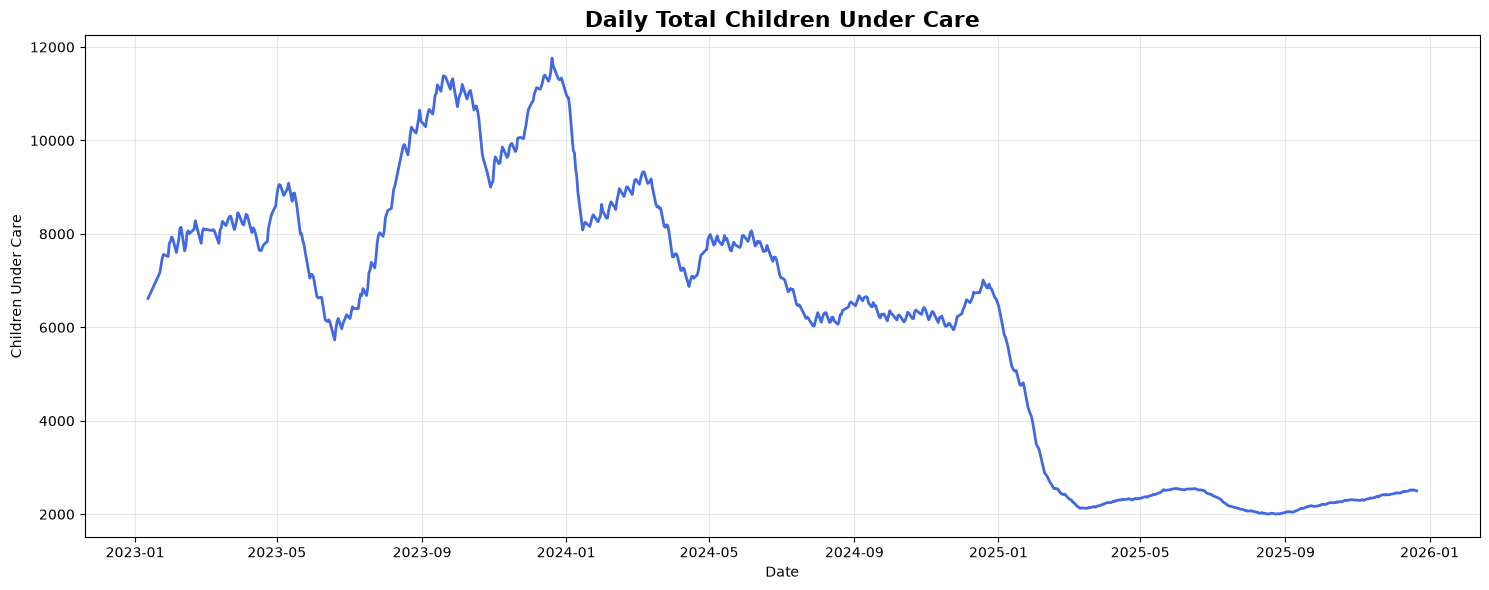

In [52]:
plt.figure(figsize=(15,6))

plt.plot(
    df["Date"],
    df["Total Children Under Care"],
    color="royalblue",
    linewidth=2
)

plt.title("Daily Total Children Under Care", fontsize=16, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Children Under Care")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("graphs/eda_01_daily_total_children_under_care.png", dpi=300)
plt.show()

### Interpretation

- The chart illustrates the daily trend of children under care throughout the reporting period.
- An upward trend indicates increasing demand on the healthcare system.
- Stable periods suggest balanced intake and discharge operations.
- Sudden increases or decreases may correspond to operational or policy changes affecting system capacity.

## 7-Day Rolling Average of Total Children Under Care

This visualization smooths daily fluctuations by calculating the 7-day moving average, making long-term healthcare capacity trends easier to observe.

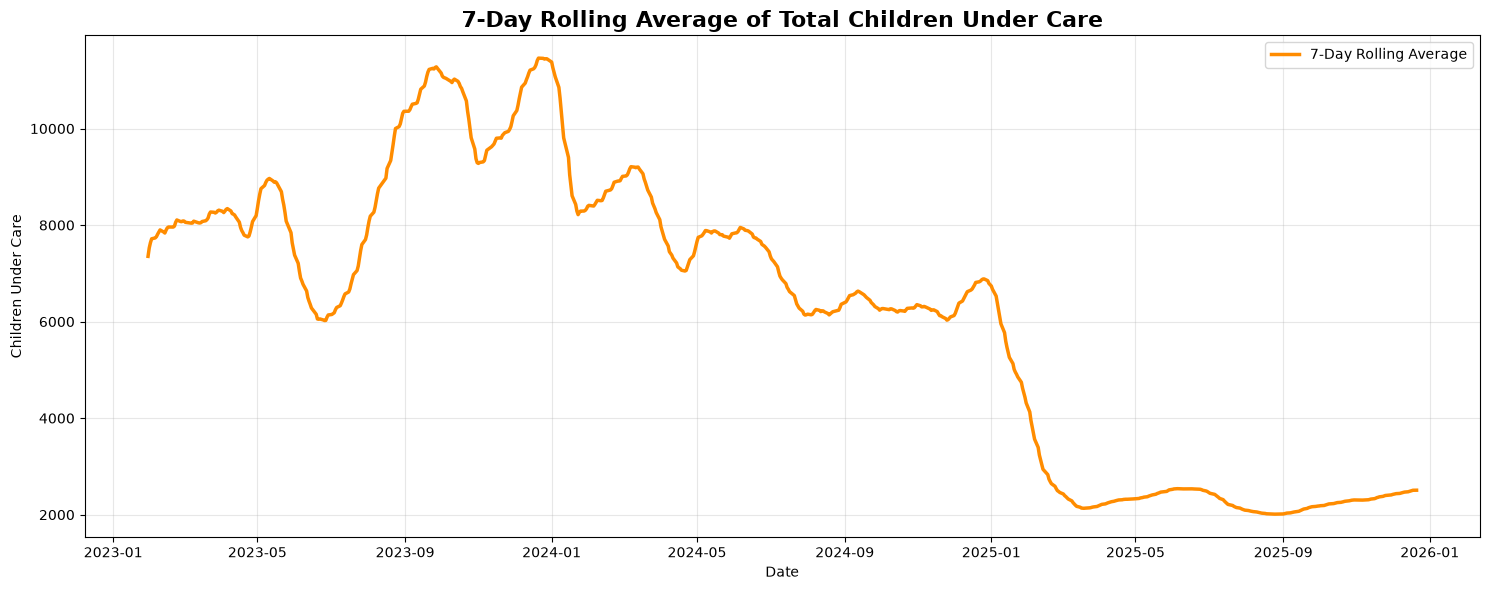

In [53]:
plt.figure(figsize=(15,6))

rolling_avg = df["Total Children Under Care"].rolling(window=7).mean()

plt.plot(
    df["Date"],
    rolling_avg,
    color="darkorange",
    linewidth=2.5,
    label="7-Day Rolling Average"
)

plt.title("7-Day Rolling Average of Total Children Under Care",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Date")
plt.ylabel("Children Under Care")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("graphs/eda_02_7day_rolling_average.png", dpi=300)
plt.show()

### Interpretation

- The 7-day rolling average reduces daily variability and highlights the underlying trend in system demand.
- Extended upward movements indicate sustained growth in healthcare workload.
- Downward movements suggest the system is gradually relieving capacity pressure.
- This metric helps identify long-term patterns that may not be visible in daily observations.

## Monthly Average Total Children Under Care

This visualization summarizes the average number of children under care each month, making long-term capacity trends easier to compare across the reporting period.

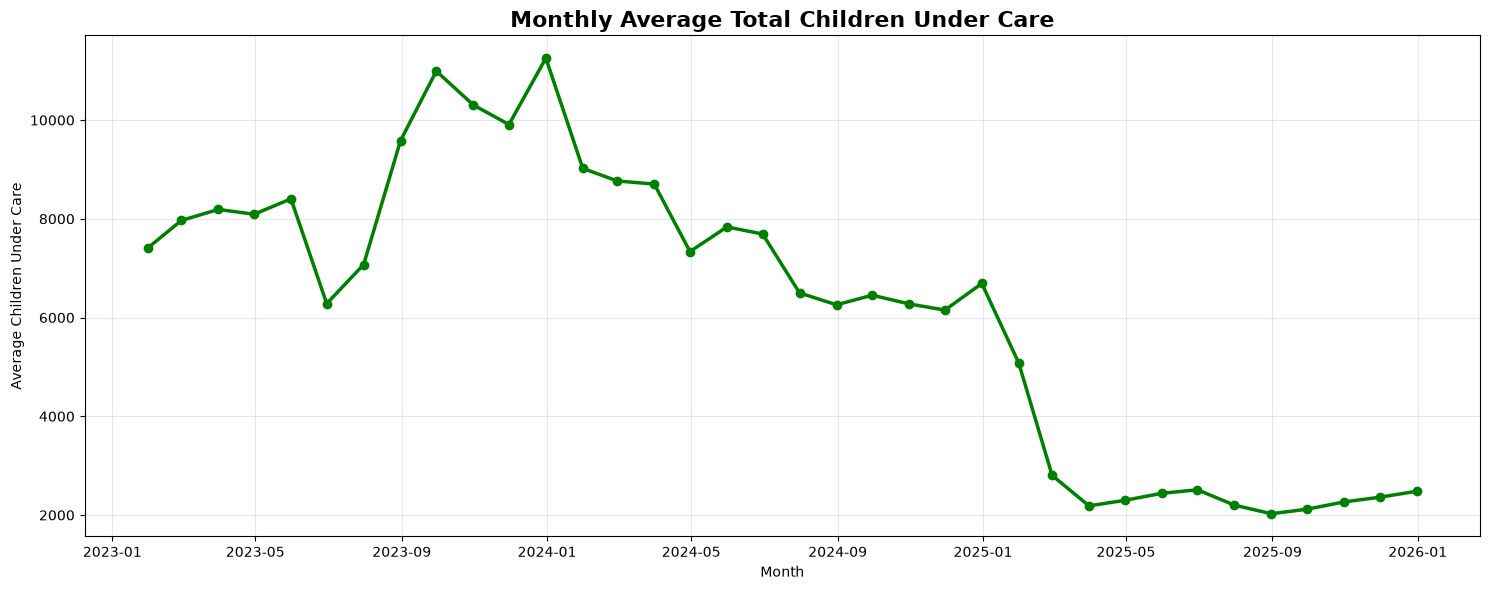

In [54]:
monthly_load = (
    df.set_index("Date")["Total Children Under Care"]
      .resample("ME")
      .mean()
)

plt.figure(figsize=(15,6))

plt.plot(
    monthly_load.index,
    monthly_load.values,
    marker="o",
    linewidth=2.5,
    color="green"
)

plt.title(
    "Monthly Average Total Children Under Care",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Average Children Under Care")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("graphs/eda_03_monthly_average_total_children_under_care.png", dpi=300)
plt.show()

### Interpretation

- Monthly averages provide a clearer view of long-term changes in care demand.
- Higher monthly values indicate periods of increased healthcare system utilization.
- Declining monthly averages suggest a gradual reduction in the overall care population.
- Comparing months helps identify seasonal or sustained capacity trends for planning purposes.

## Monthly Net Intake Pressure Trend

This visualization shows the average monthly net intake pressure by comparing transfers into HHS with discharges from HHS, indicating whether the system is accumulating or relieving care demand.


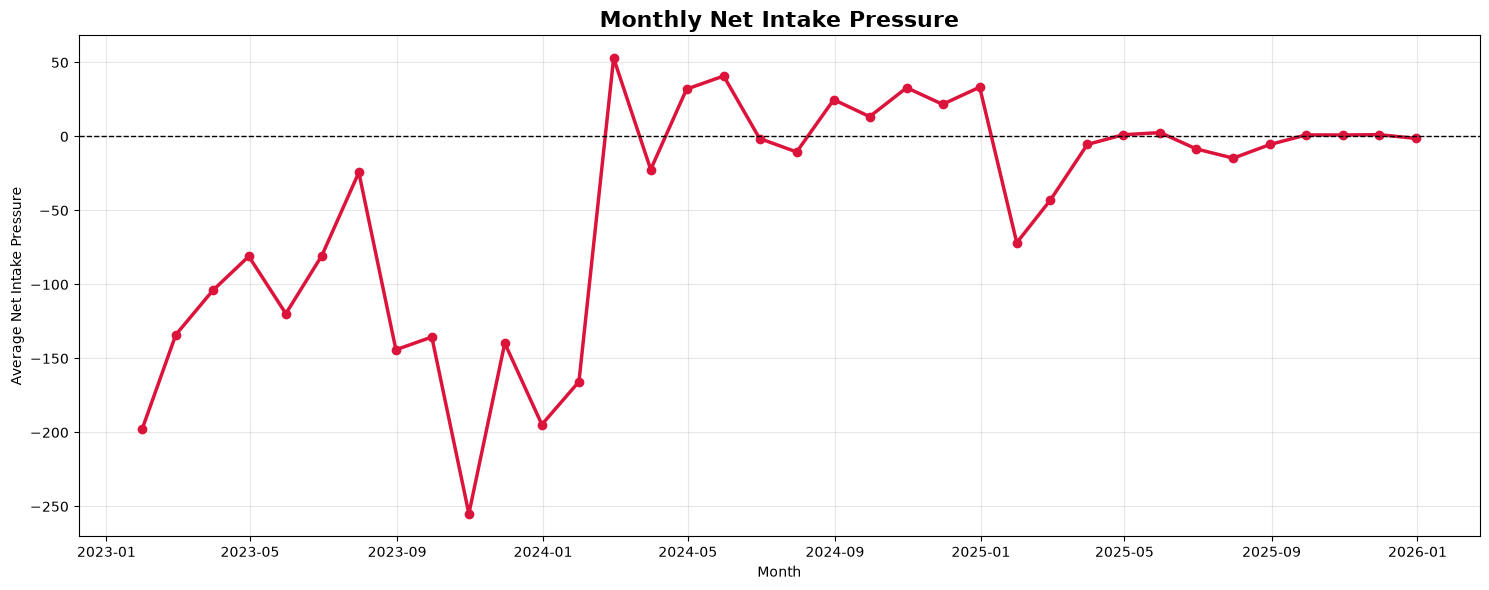

In [55]:
monthly_intake = (
    df.set_index("Date")["Net Intake Pressure"]
      .resample("ME")
      .mean()
)

plt.figure(figsize=(15,6))

plt.plot(
    monthly_intake.index,
    monthly_intake.values,
    marker="o",
    linewidth=2.5,
    color="crimson"
)

plt.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.title(
    "Monthly Net Intake Pressure",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Average Net Intake Pressure")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("graphs/eda_04_monthly_net_intake_pressure.png", dpi=300)
plt.show()

### Interpretation

- Positive values indicate transfers exceeded discharges, increasing system pressure.
- Negative values indicate more children were discharged than transferred, reducing care demand.
- Months close to zero reflect a balanced flow between inflow and outflow.
- This trend helps identify periods of sustained capacity buildup or relief.

## Care Load Volatility Index Trend

This visualization shows how much the total healthcare care load changes over time. Higher values indicate greater fluctuations in workload, while lower values indicate a more stable healthcare system.

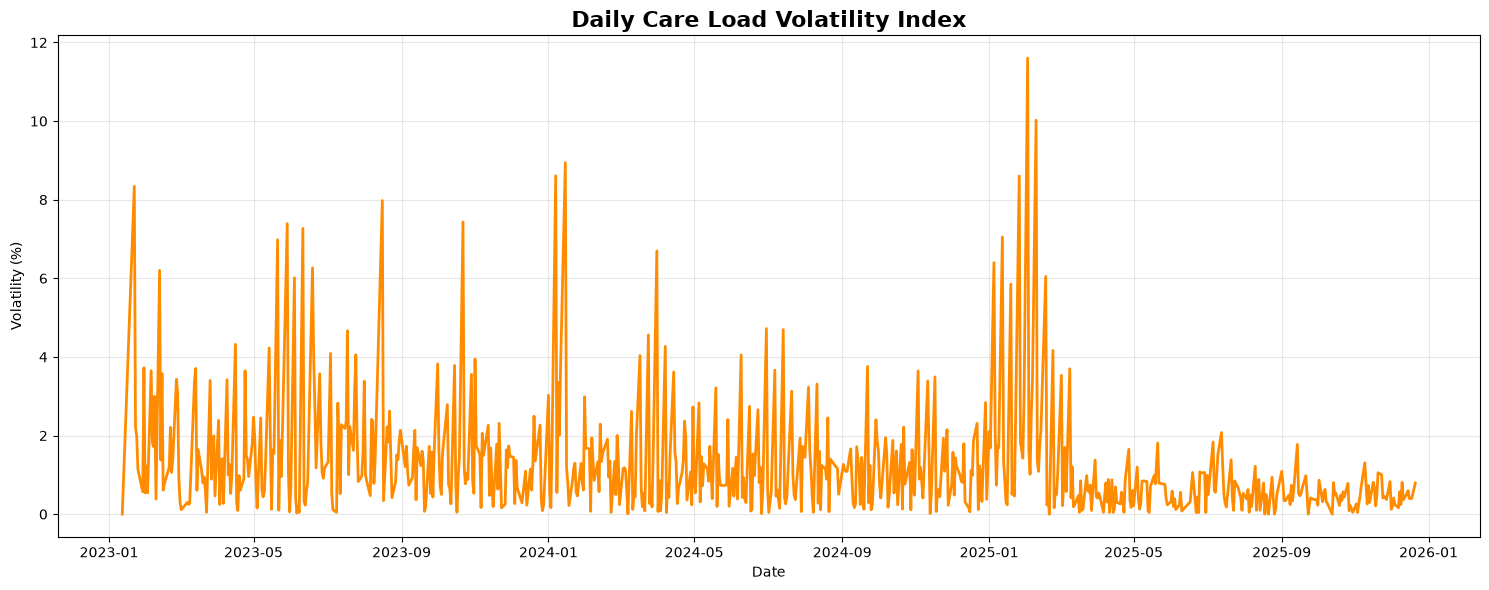

In [56]:
plt.figure(figsize=(15,6))

plt.plot(
    df["Date"],
    df["Care Load Volatility Index"],
    color="darkorange",
    linewidth=2
)

plt.title(
    "Daily Care Load Volatility Index",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Volatility (%)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("graphs/eda_05_care_load_volatility_index.png", dpi=300)
plt.show()

## Interpretation

- Higher peaks indicate sudden increases or decreases in healthcare workload.
- Lower values represent stable daily care operations with minimal fluctuations.
- Periods of sustained volatility may require additional staffing and resource planning.
- Overall, declining volatility suggests the healthcare system is becoming more stable over time.

## Monthly Care Load Volatility Index

This visualization presents the average monthly care load volatility, helping identify periods when the healthcare system experienced relatively stable or unstable workloads.

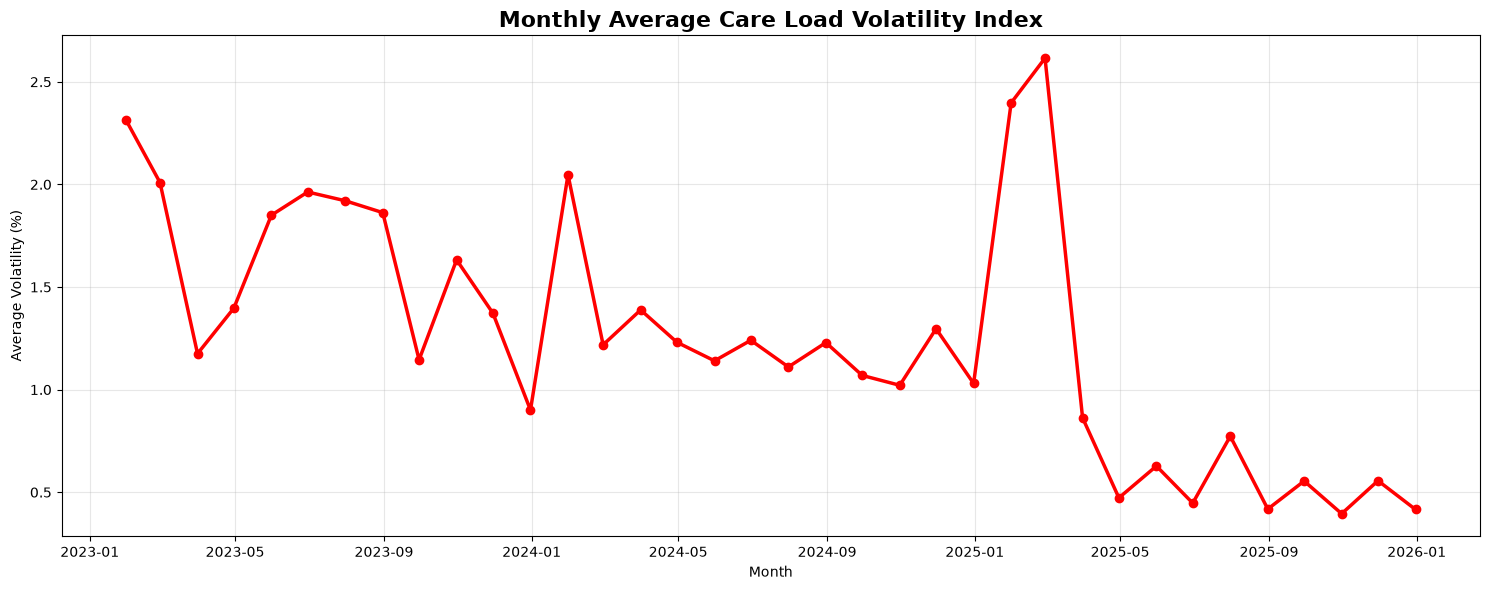

In [57]:
monthly_volatility = (
    df.set_index("Date")["Care Load Volatility Index"]
      .resample("ME")
      .mean()
)

plt.figure(figsize=(15,6))

plt.plot(
    monthly_volatility.index,
    monthly_volatility.values,
    marker="o",
    linewidth=2.5,
    color="red"
)

plt.title(
    "Monthly Average Care Load Volatility Index",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Average Volatility (%)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("graphs/eda_06_monthly_care_load_volatility.png", dpi=300)
plt.show()

### Interpretation

-Higher monthly averages indicate periods of increased instability in healthcare workload.
- Lower volatility reflects more consistent and predictable care demand.
- Volatility peaks highlight months requiring closer operational monitoring.
- The decline in monthly volatility toward the later period suggests improving system stability and more balanced care operations.


## Monthly Net Intake Pressure Trend

This visualization shows the average monthly net intake pressure by comparing transfers into HHS care with discharges. It helps identify months when the healthcare system experienced higher or lower intake pressure.

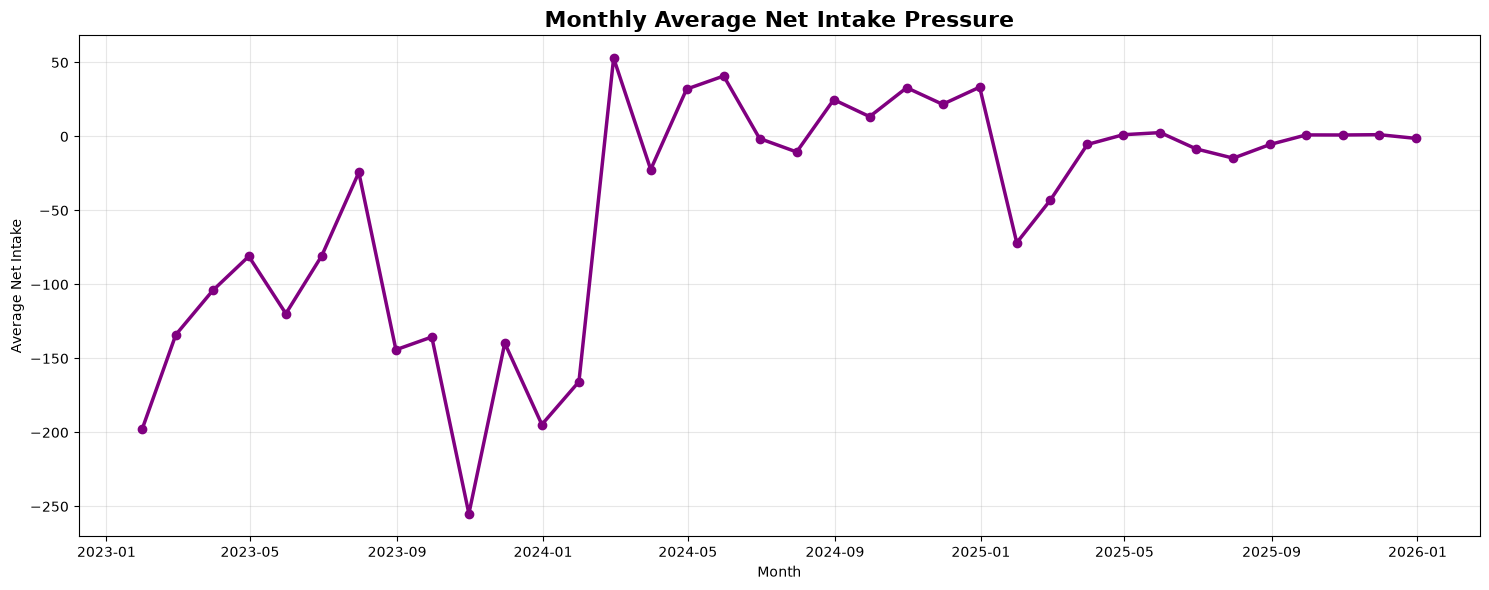

In [58]:
monthly_net_intake = (
    df.set_index("Date")["Net Intake Pressure"]
      .resample("ME")
      .mean()
)

plt.figure(figsize=(15,6))

plt.plot(
    monthly_net_intake.index,
    monthly_net_intake.values,
    marker="o",
    linewidth=2.5,
    color="purple"
)

plt.title(
    "Monthly Average Net Intake Pressure",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Average Net Intake")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("graphs/eda_07_monthly_net_intake_pressure.png", dpi=300)
plt.show()

### Interpretation

- Positive values indicate months where transfers exceeded discharges, increasing system pressure.
- Negative values indicate months where discharges outpaced transfers, reducing overall care load.
- Sharp changes highlight periods of operational imbalance requiring attention.
- The overall trend reflects how effectively the healthcare system managed patient flow over time.

## Monthly Backlog Accumulation Rate Trend

This visualization shows the average monthly backlog accumulation rate, indicating how much of the total care load remained in CBP custody before being transferred to HHS care.

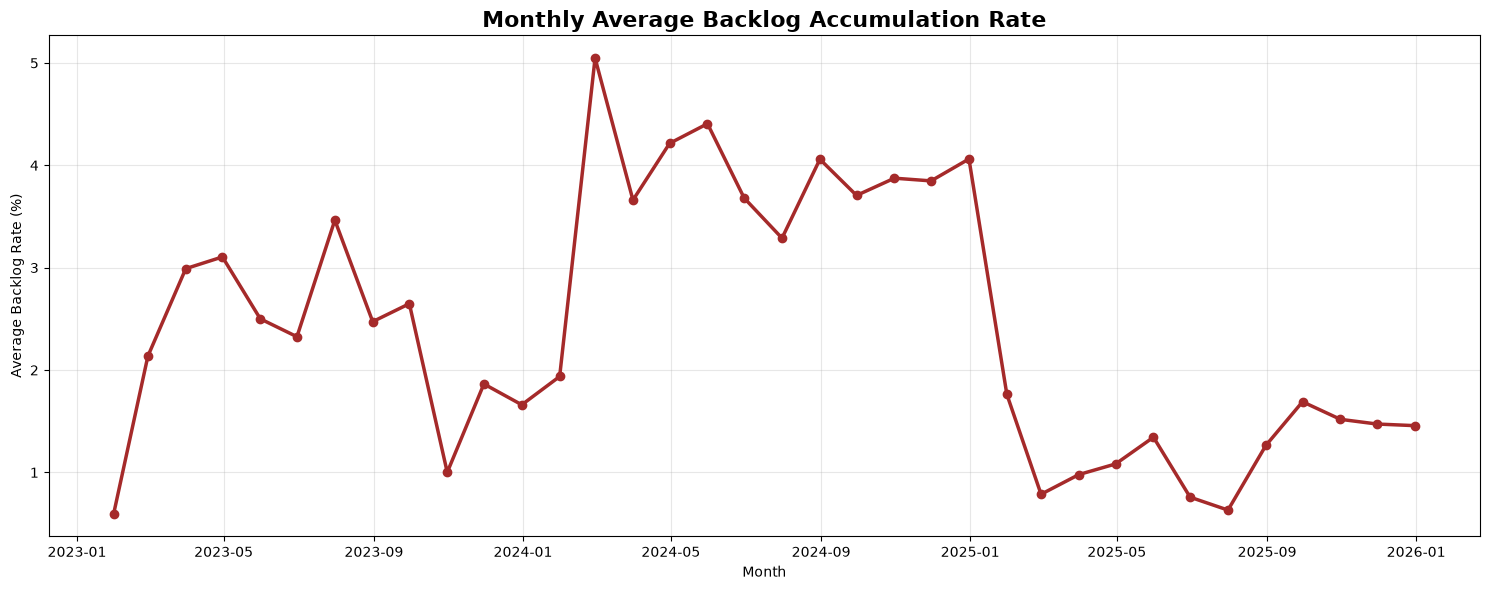

In [59]:
monthly_backlog = (
    df.set_index("Date")["Backlog Accumulation Rate"]
      .resample("ME")
      .mean()
)

plt.figure(figsize=(15,6))

plt.plot(
    monthly_backlog.index,
    monthly_backlog.values,
    marker="o",
    linewidth=2.5,
    color="brown"
)

plt.title(
    "Monthly Average Backlog Accumulation Rate",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Average Backlog Rate (%)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("graphs/eda_08_monthly_backlog_accumulation_rate.png", dpi=300)
plt.show()

### Interpretation

- Higher backlog rates indicate a larger proportion of children remaining in CBP custody.
- Lower values suggest quicker transfers to HHS care and reduced waiting time.
- Declining backlog reflects improved care flow and reduced capacity pressure.
- Stable backlog levels indicate consistent system performance over time.


## Monthly Discharge Offset Ratio Trend

This visualization shows the average monthly discharge offset ratio, indicating how effectively discharges from HHS reduced the overall healthcare care load over time.

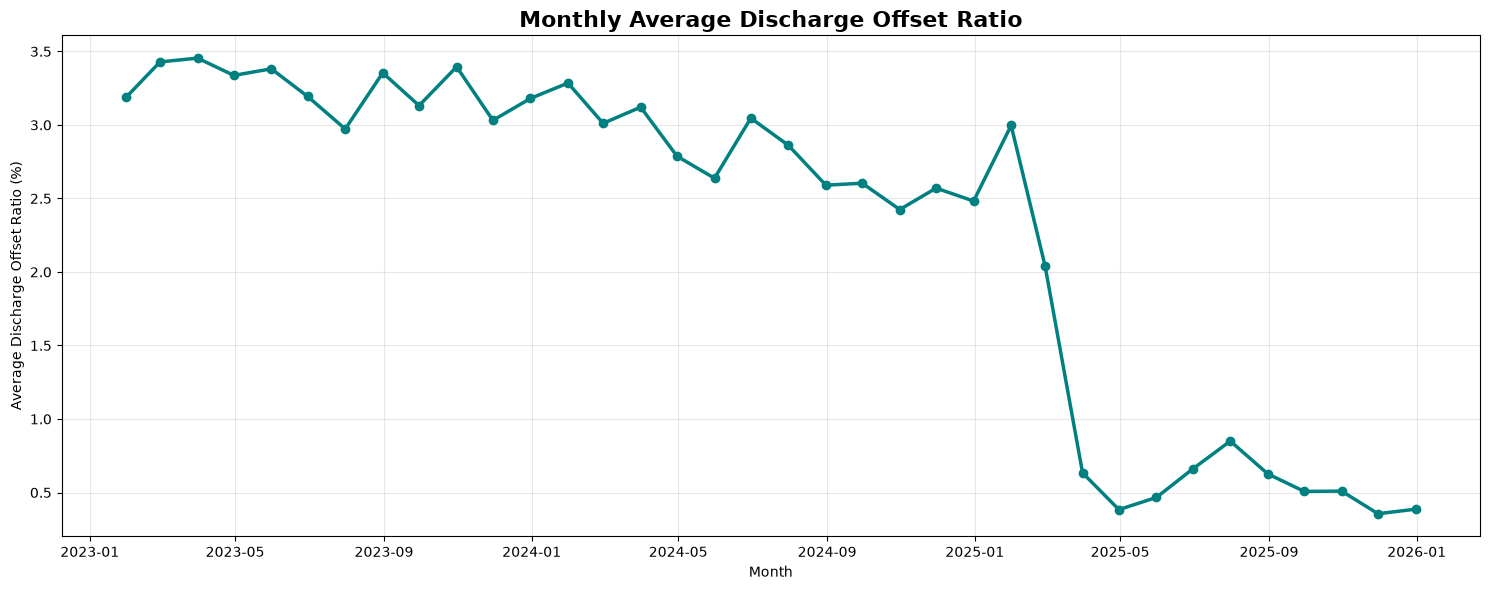

In [60]:
monthly_discharge = (
    df.set_index("Date")["Discharge Offset Ratio"]
      .resample("ME")
      .mean()
)

plt.figure(figsize=(15,6))

plt.plot(
    monthly_discharge.index,
    monthly_discharge.values,
    marker="o",
    linewidth=2.5,
    color="teal"
)

plt.title(
    "Monthly Average Discharge Offset Ratio",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Average Discharge Offset Ratio (%)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("graphs/eda_09_monthly_discharge_offset_ratio.png", dpi=300)
plt.show()

### Interpretation

- Higher values indicate more effective discharge activity in reducing the overall care load.
- Lower values suggest slower system relief through discharges.
- Month-to-month changes reflect variations in discharge efficiency.
- A stable or increasing trend indicates sustained improvement in balancing healthcare capacity.

## Correlation Heatmap

Shows relationships among all healthcare metrics.

In [61]:
df.columns = df.columns.str.replace("*", "", regex=False).str.strip()

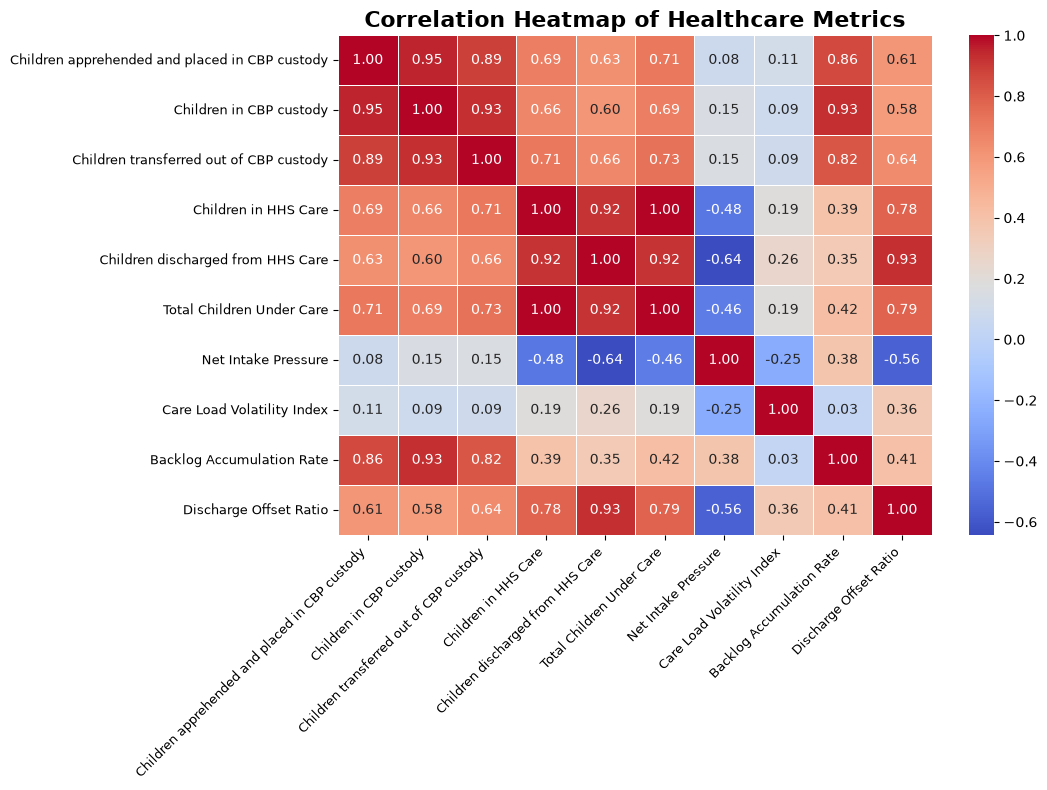

In [62]:
import seaborn as sns

corr_columns = [
    "Children apprehended and placed in CBP custody",
    "Children in CBP custody",
    "Children transferred out of CBP custody",
    "Children in HHS Care",
    "Children discharged from HHS Care",
    "Total Children Under Care",
    "Net Intake Pressure",
    "Care Load Volatility Index",
    "Backlog Accumulation Rate",
    "Discharge Offset Ratio"
]

plt.figure(figsize=(11,8))

sns.heatmap(
    df[corr_columns].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.title(
    "Correlation Heatmap of Healthcare Metrics",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("graphs/eda_10_correlation_heatmap.png", dpi=300)
plt.show()


### Interpretation

- Strong positive correlations indicate metrics that increase together.
- Negative correlations highlight inverse healthcare relationships.
- Highly correlated variables reveal key drivers of system capacity.
- The heatmap helps identify patterns for forecasting and planning.

## CBP vs HHS Care Load Comparison

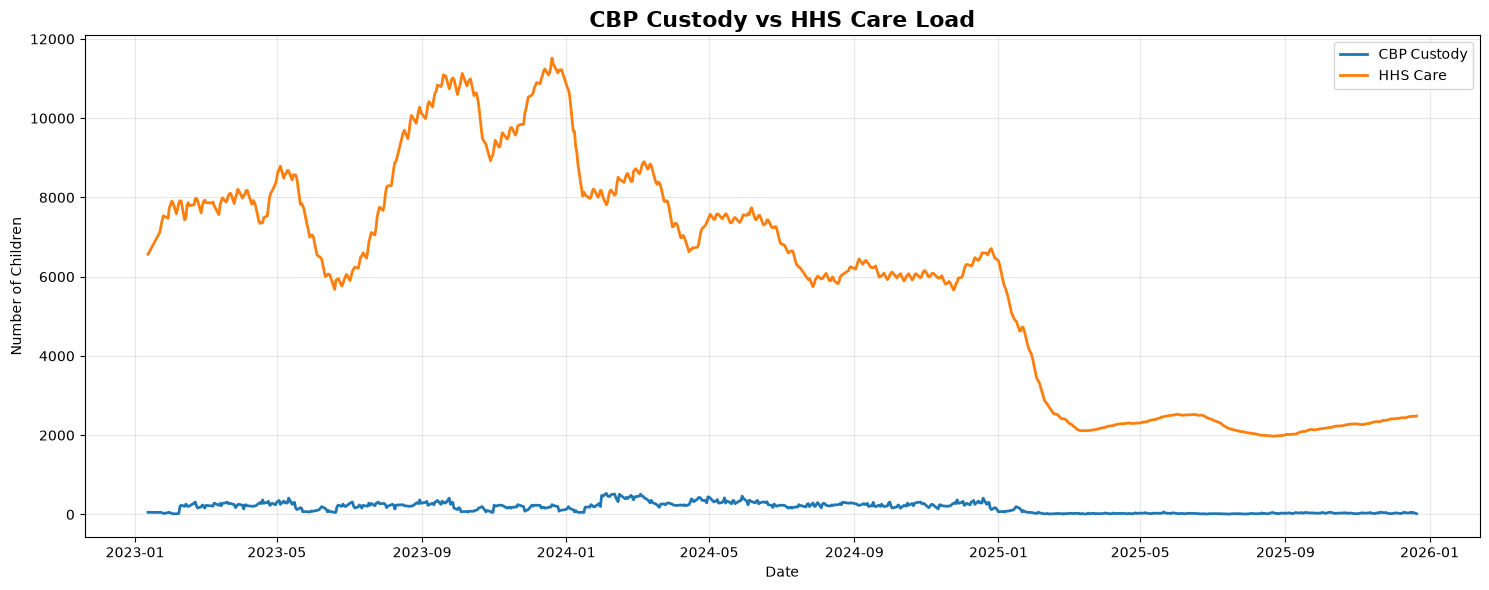

In [63]:
plt.figure(figsize=(15,6))

plt.plot(
    df["Date"],
    df["Children in CBP custody"],
    label="CBP Custody",
    linewidth=2
)

plt.plot(
    df["Date"],
    df["Children in HHS Care"],
    label="HHS Care",
    linewidth=2
)

plt.title(
    "CBP Custody vs HHS Care Load",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Number of Children")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("graphs/eda_11_cbp_vs_hhs_care_load.png", dpi=300)
plt.show()

### Interpretation

- The chart compares the care load managed by CBP and HHS over time.
- A higher HHS population indicates successful transfers from CBP into long-term care.
- Large differences between the two lines may indicate temporary capacity imbalance.
- Similar movement patterns suggest coordinated care transitions between both systems.

## Distribution of Daily Children Under Care

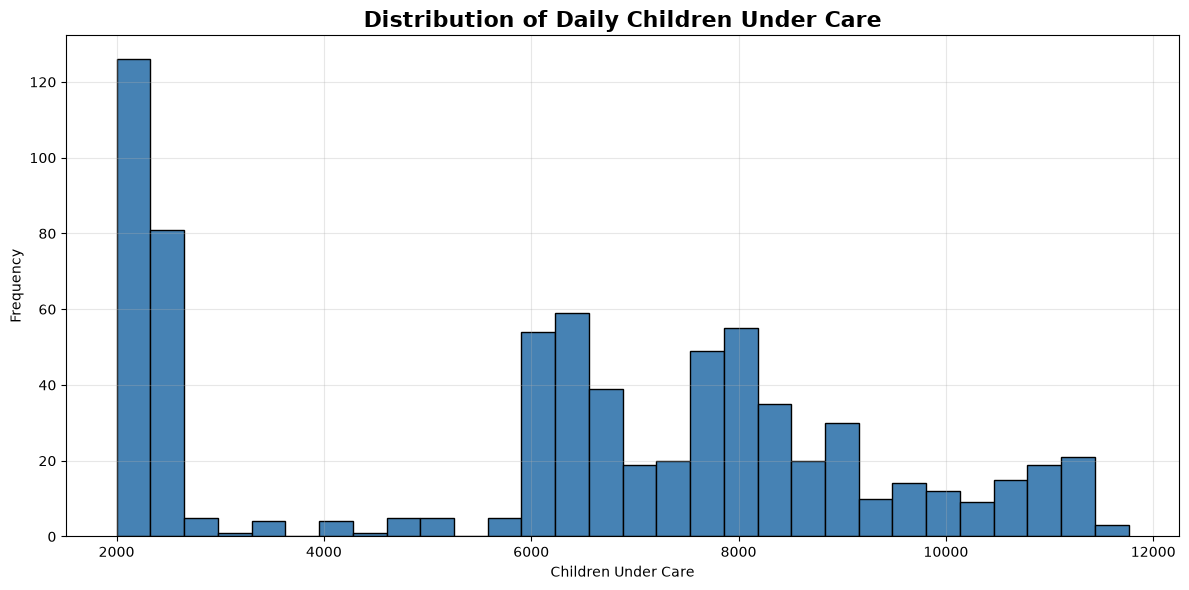

In [64]:
plt.figure(figsize=(12,6))

plt.hist(
    df["Total Children Under Care"],
    bins=30,
    color="steelblue",
    edgecolor="black"
)

plt.title(
    "Distribution of Daily Children Under Care",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Children Under Care")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("graphs/eda_12_distribution_total_children_under_care.png", dpi=300)
plt.show()

### Interpretation

- The histogram shows how frequently different healthcare workload levels occurred.
- A right-skewed distribution indicates occasional periods of exceptionally high system demand.
- Concentration around lower values suggests that recent operations stabilized at reduced care levels.
- Understanding the distribution helps identify normal operating ranges and potential outlier events.

## Comparative Time Analysis

This analysis compares the average monthly healthcare workload across different years to identify long-term changes in system capacity and operational demand.

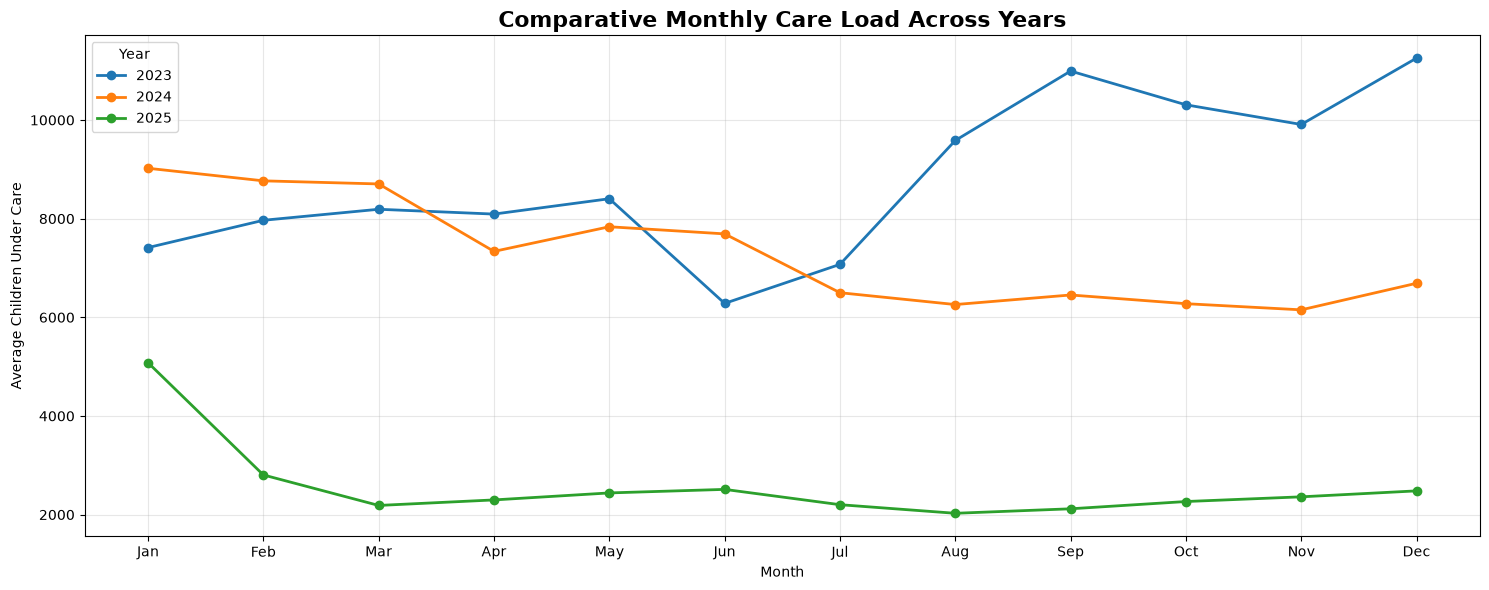

In [65]:
# Comparative Time Analysis (Year-over-Year)

comparison_df = df.copy()

comparison_df["Year"] = comparison_df["Date"].dt.year
comparison_df["Month"] = comparison_df["Date"].dt.month_name().str[:3]

month_order = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
]

comparison_df["Month"] = pd.Categorical(
    comparison_df["Month"],
    categories=month_order,
    ordered=True
)

monthly_compare = (
    comparison_df
    .groupby(["Year","Month"])["Total Children Under Care"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(15,6))

for year in sorted(monthly_compare["Year"].unique()):
    yearly = monthly_compare[monthly_compare["Year"] == year]

    plt.plot(
        yearly["Month"],
        yearly["Total Children Under Care"],
        marker="o",
        linewidth=2,
        label=str(year)
    )

plt.title(
    "Comparative Monthly Care Load Across Years",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Average Children Under Care")

plt.legend(title="Year")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Graphs/eda_12_comparative_time_analysis.png",
    dpi=300
)

plt.show()

### Interpretation

- The chart compares average monthly healthcare demand across multiple years.
- Differences between yearly trends help identify long-term changes in system capacity.
- Seasonal peaks and declines become easier to recognize across years.
- This comparison supports strategic planning and resource allocation decisions.

## Load Pressure Analysis


This analysis evaluates how operational pressure changes over time by comparing total children under care with the healthcare system's net intake pressure.

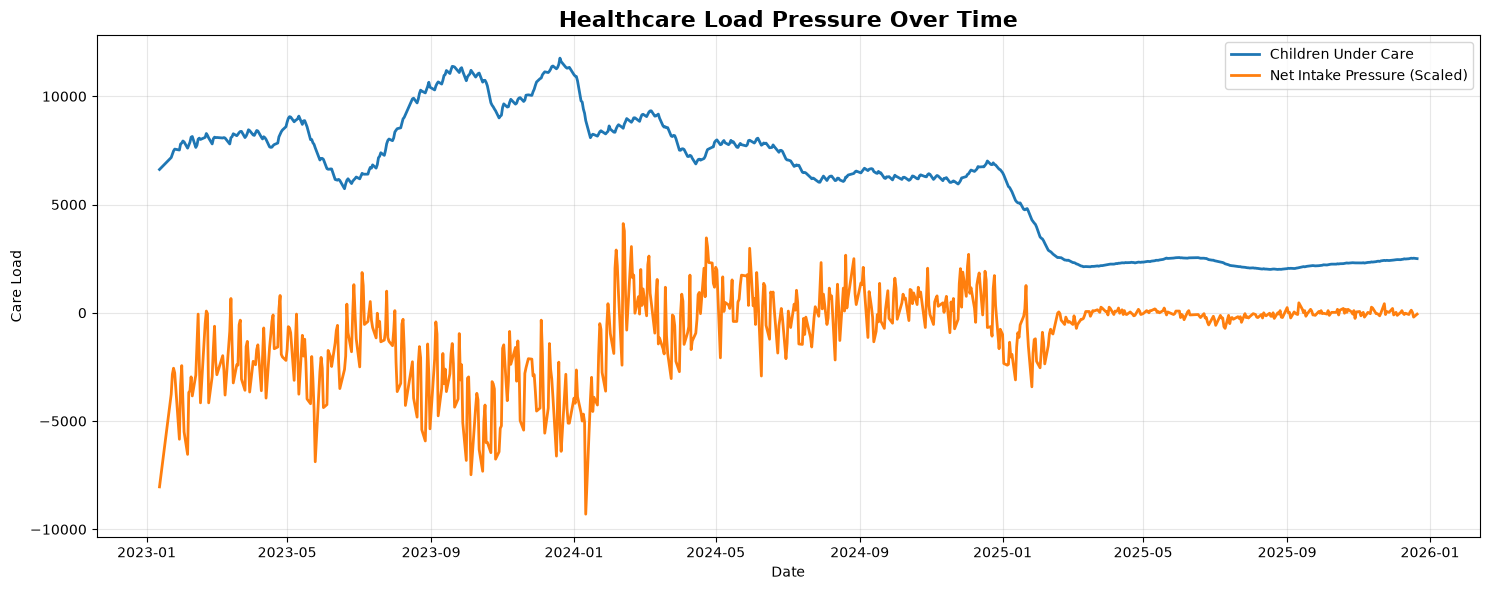

In [66]:
plt.figure(figsize=(15,6))

plt.plot(
    df["Date"],
    df["Total Children Under Care"],
    label="Children Under Care",
    linewidth=2
)

plt.plot(
    df["Date"],
    df["Net Intake Pressure"]*20,
    label="Net Intake Pressure (Scaled)",
    linewidth=2
)

plt.title(
    "Healthcare Load Pressure Over Time",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Care Load")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Graphs/eda_13_load_pressure_analysis.png",
    dpi=300
)

plt.show()

###  Interpretation

- The chart compares total healthcare demand with operational intake pressure.
- Periods where both lines increase simultaneously indicate higher system stress.
- Declining intake pressure alongside stable care load suggests improved operational efficiency.
- This analysis helps identify periods requiring additional staffing or resource allocation.

## Capacity Utilization Analysis

This analysis measures how efficiently the healthcare system utilized available care capacity over time by comparing children receiving HHS care against the total number of children under care.

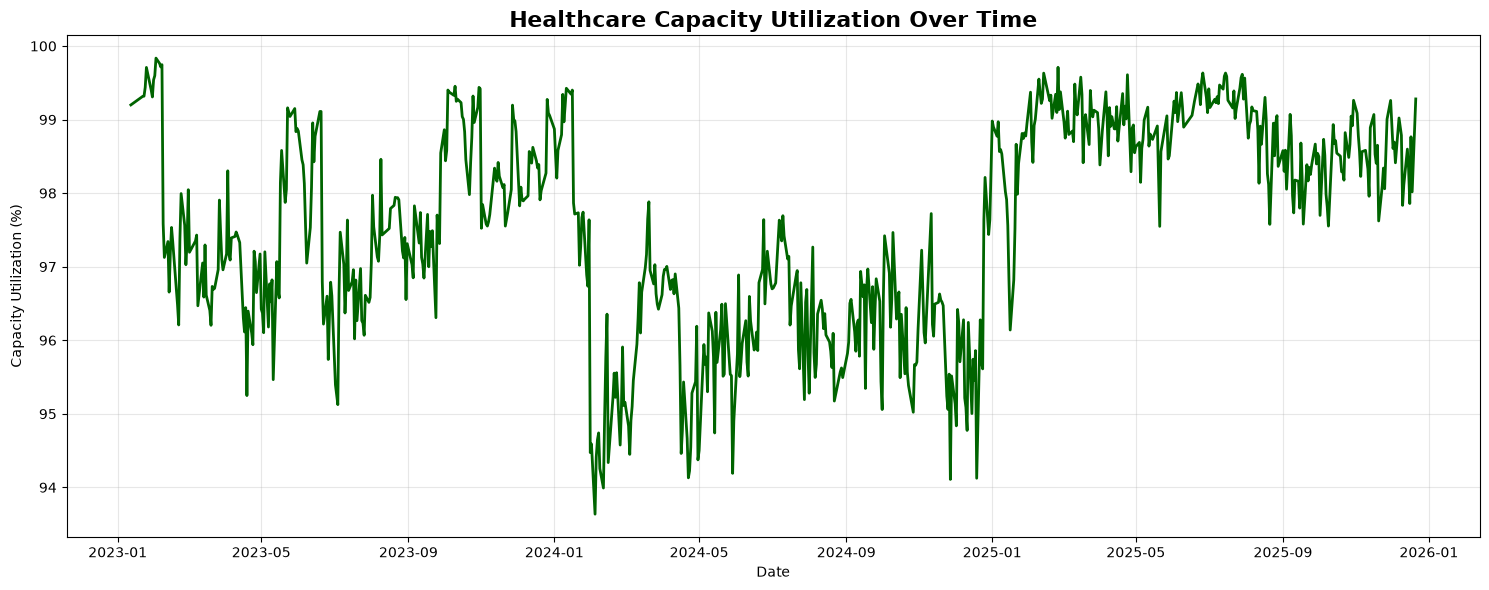

In [67]:
capacity_df = df.copy()

capacity_df["Capacity Utilization (%)"] = (
    capacity_df["Children in HHS Care"] /
    capacity_df["Total Children Under Care"]
) * 100

plt.figure(figsize=(15,6))

plt.plot(
    capacity_df["Date"],
    capacity_df["Capacity Utilization (%)"],
    color="darkgreen",
    linewidth=2
)

plt.title(
    "Healthcare Capacity Utilization Over Time",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Capacity Utilization (%)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Graphs/eda_14_capacity_utilization_analysis.png",
    dpi=300
)

plt.show()

### Interpretation

- Higher utilization indicates a larger proportion of children successfully transitioned into HHS care.
- Lower utilization may suggest limited placement capacity or operational constraints.
- Stable utilization reflects balanced healthcare system performance.
- This metric helps evaluate overall efficiency of capacity management over time.

## Peak Demand Analysis

This analysis identifies the highest healthcare demand periods to understand when the system experienced maximum operational pressure.

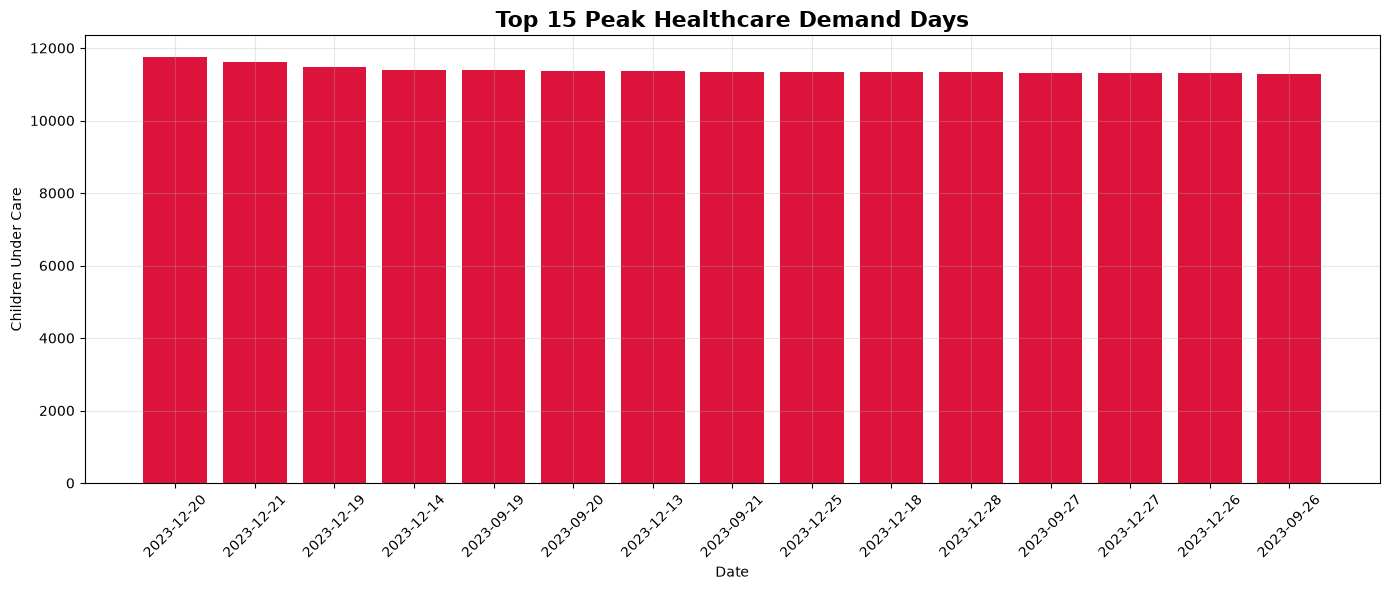

In [68]:
peak_df = df.copy()

top_15 = peak_df.nlargest(
    15,
    "Total Children Under Care"
)

plt.figure(figsize=(14,6))

plt.bar(
    top_15["Date"].dt.strftime("%Y-%m-%d"),
    top_15["Total Children Under Care"],
    color="crimson"
)

plt.xticks(rotation=45)

plt.title(
    "Top 15 Peak Healthcare Demand Days",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Children Under Care")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Graphs/eda_15_peak_demand_analysis.png",
    dpi=300
)

plt.show()

### Interpretation

- The chart highlights the highest-demand periods during the study.
- These dates represent peak operational workload.
- Identifying peak periods supports workforce planning and emergency preparedness.
- Healthcare administrators can use these insights for future capacity planning.

## Operational Efficiency Analysis


This analysis compares admissions into CBP custody with successful transfers to HHS care to evaluate operational efficiency.

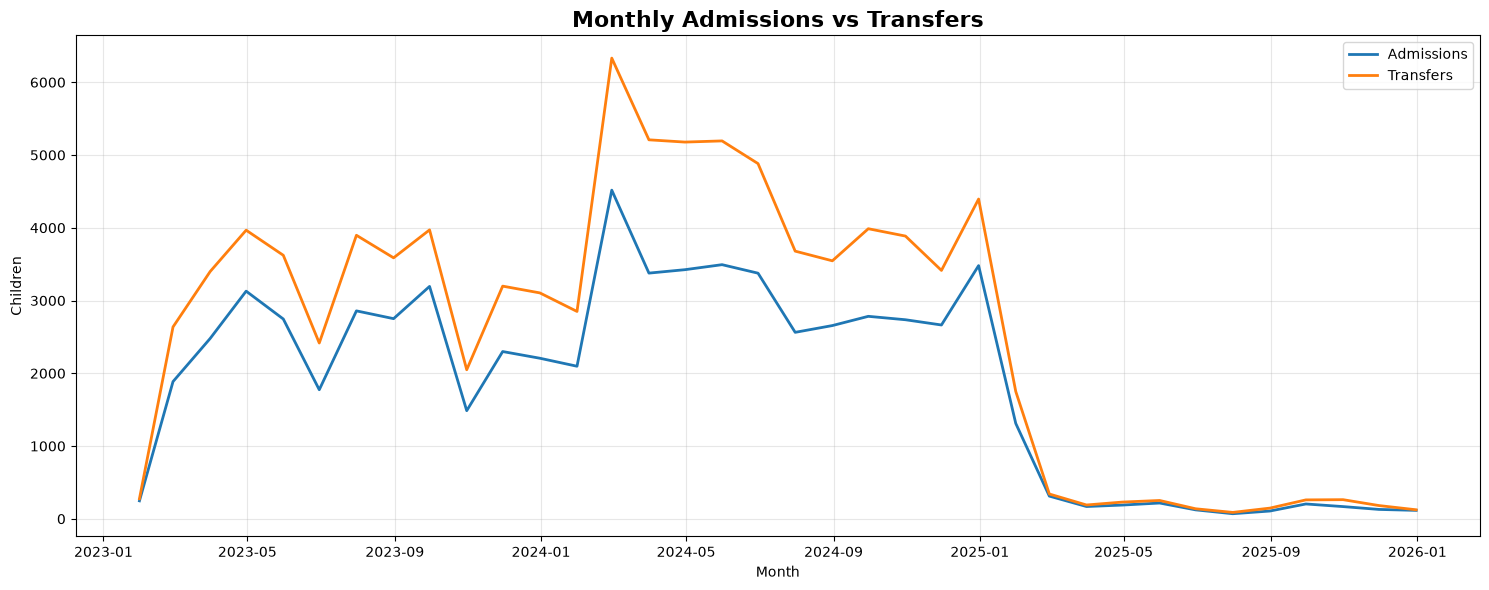

In [69]:
monthly_efficiency = (
    df.set_index("Date")[
        [
            "Children apprehended and placed in CBP custody",
            "Children transferred out of CBP custody"
        ]
    ]
    .resample("ME")
    .sum()
)

plt.figure(figsize=(15,6))

plt.plot(
    monthly_efficiency.index,
    monthly_efficiency[
        "Children apprehended and placed in CBP custody"
    ],
    label="Admissions",
    linewidth=2
)

plt.plot(
    monthly_efficiency.index,
    monthly_efficiency[
        "Children transferred out of CBP custody"
    ],
    label="Transfers",
    linewidth=2
)

plt.title(
    "Monthly Admissions vs Transfers",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Children")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Graphs/eda_16_operational_efficiency.png",
    dpi=300
)

plt.show()

### Interpretation

- Similar trends indicate balanced healthcare operations.
- Large gaps suggest periods of operational backlog.
- Higher transfers relative to admissions indicate improved system efficiency.
- This comparison evaluates the effectiveness of patient movement through the care system.

# Executive Insights Summary

This section summarizes the key operational findings obtained from exploratory data analysis before building predictive models.

In [70]:
summary = pd.DataFrame({

    "Metric":[
        "Highest Children Under Care",
        "Lowest Children Under Care",
        "Average Children Under Care",
        "Average Net Intake Pressure",
        "Average Care Load Volatility (%)",
        "Average Capacity Utilization (%)",
        "Highest Backlog Accumulation (%)"
    ],

    "Value":[
        round(df["Total Children Under Care"].max(),2),
        round(df["Total Children Under Care"].min(),2),
        round(df["Total Children Under Care"].mean(),2),
        round(df["Net Intake Pressure"].mean(),2),
        round(df["Care Load Volatility Index"].mean(),2),
        round(capacity_df["Capacity Utilization (%)"].mean(),2),
        round(df["Backlog Accumulation Rate"].max(),2)
    ]

})

summary

,Metric,Value
0,Highest Children Under Care,11762.00
1,Lowest Children Under Care,2002.00
2,Average Children Under Care,6232.77
3,Average Net Intake Pressure,-44.74
4,Average Care Load Volatility (%),1.24
5,Average Capacity Utilization (%),97.53
6,Highest Backlog Accumulation (%),6.36


### Save Summary

In [71]:
summary.to_csv(
    "Outputs/executive_summary.csv",
    index=False
)

summary

,Metric,Value
0,Highest Children Under Care,11762.00
1,Lowest Children Under Care,2002.00
2,Average Children Under Care,6232.77
3,Average Net Intake Pressure,-44.74
4,Average Care Load Volatility (%),1.24
5,Average Capacity Utilization (%),97.53
6,Highest Backlog Accumulation (%),6.36


## Interpretation

- Healthcare demand declined substantially over the study period.
- Capacity utilization remained consistently high, indicating effective placement into HHS care.
- Operational volatility reduced during later months, reflecting improved system stability.
- Backlog accumulation also declined, suggesting improved patient flow and reduced pressure.
- These findings provide a strong foundation for predictive healthcare capacity planning.

# Machine Learning Forecasting

This section develops predictive models to forecast future healthcare demand.

Two forecasting approaches are used:

- Linear Regression (Baseline)
- Facebook Prophet (Time-Series Forecasting)

## Prepare Forecast Dataset

In [72]:
forecast_df = df.copy()

forecast_df = forecast_df[[
    "Date",
    "Total Children Under Care"
]].copy()

forecast_df.head()

,Date,Total Children Under Care
0,2023-01-12,6619.0
1,2023-01-22,7171.0
2,2023-01-23,7330.0
3,2023-01-24,7475.0
4,2023-01-25,7560.0


### Interpretation

- Only the variables required for forecasting are selected.
- The dataset is now ready for predictive modeling.

## Prepare Prophet Dataset

In [73]:
prophet_df = forecast_df.rename(
    columns={
        "Date":"ds",
        "Total Children Under Care":"y"
    }
)

prophet_df.head()

,ds,y
0,2023-01-12,6619.0
1,2023-01-22,7171.0
2,2023-01-23,7330.0
3,2023-01-24,7475.0
4,2023-01-25,7560.0


Prophet requires:

- ds → Date
- y → Target Variable

The dataset has been converted into Prophet's required format.

## Train Test Split (Linear Regression)

In [74]:
from sklearn.model_selection import train_test_split

forecast_df["Day_Number"] = (
    forecast_df["Date"] -
    forecast_df["Date"].min()
).dt.days

X = forecast_df[["Day_Number"]]

y = forecast_df["Total Children Under Care"]

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    shuffle=False
)

### Train Linear Regression

In [75]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train,y_train)

y_pred = lr_model.predict(X_test)

The Linear Regression model learns the long-term trend in healthcare demand using time as the predictor.

## Evaluate Linear Regression Model

In [76]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 1294.11
RMSE : 1374.53
R²   : -59.5807


- MAE measures the average prediction error.
- RMSE penalizes larger prediction errors.
- R² indicates how well the model explains the variation in healthcare demand.
- These metrics provide a baseline before applying a more advanced forecasting model.

## Actual vs Predicted Healthcare Demand

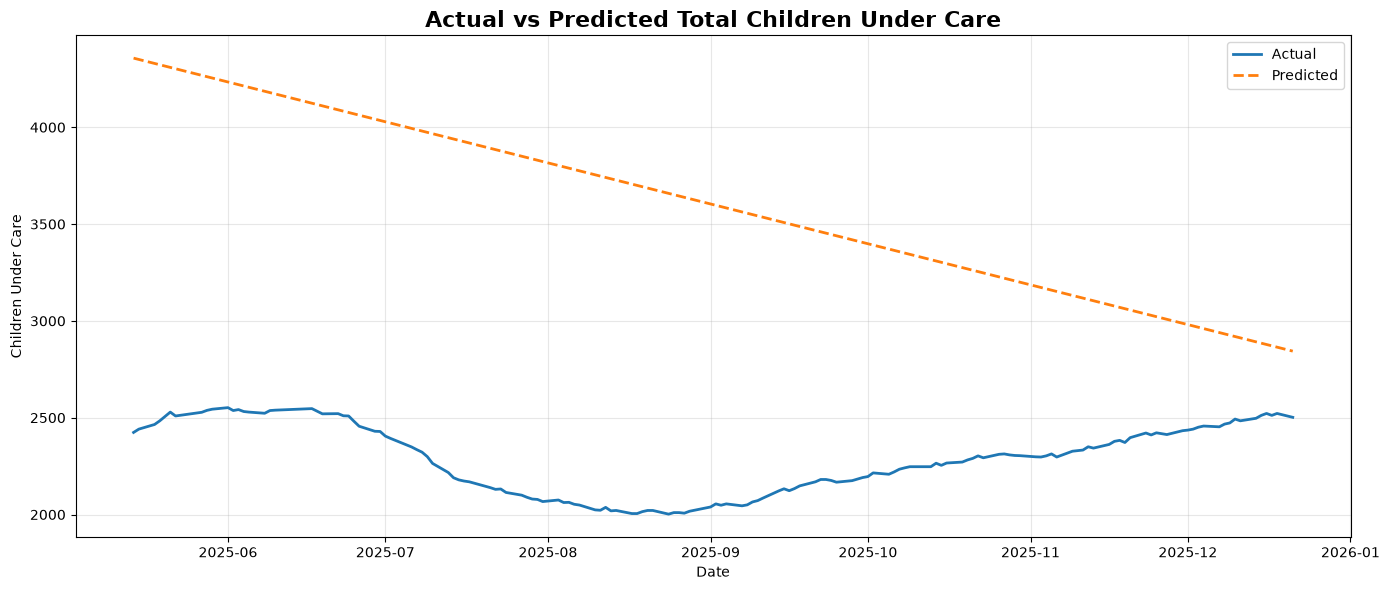

In [77]:
plt.figure(figsize=(14,6))

plt.plot(
    forecast_df.loc[y_test.index, "Date"],
    y_test,
    label="Actual",
    linewidth=2
)

plt.plot(
    forecast_df.loc[y_test.index, "Date"],
    y_pred,
    "--",
    label="Predicted",
    linewidth=2
)

plt.title(
    "Actual vs Predicted Total Children Under Care",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Children Under Care")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Graphs/ml_01_actual_vs_predicted.png",
    dpi=300
)

plt.show()

### Interpretation

- The blue line represents the actual healthcare demand.
- The dashed line represents the Linear Regression prediction.
- Differences between the two indicate forecasting error.
- Linear Regression captures long-term movement but cannot model seasonal patterns.

In [78]:
%pip install prophet

Note: you may need to restart the kernel to use updated packages.


In [79]:
from prophet import Prophet

prophet_model = Prophet()

prophet_model.fit(prophet_df)

11:47:56 - cmdstanpy - INFO - Chain [1] start processing
11:47:56 - cmdstanpy - INFO - Chain [1] done processing


The Prophet model automatically learns long-term trends and seasonal behaviour from historical healthcare demand.

## 90-Day Healthcare Demand Forecast

In [80]:
future = prophet_model.make_future_dataframe(
    periods=90
)

forecast = prophet_model.predict(future)

forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
805,2026-03-17,86.722053,-1056.138249,470.354224,-151.216341,296.184253,-341.455999,-341.455999,-341.455999,201.039158,201.039158,201.039158,-542.495157,-542.495157,-542.495157,0.0,0.0,0.0,-254.733946
806,2026-03-18,78.015579,-949.824533,532.623833,-165.022033,292.111640,-314.030471,-314.030471,-314.030471,233.471386,233.471386,233.471386,-547.501858,-547.501858,-547.501858,0.0,0.0,0.0,-236.014892
807,2026-03-19,69.309105,-1033.235459,502.501439,-178.429588,288.228351,-336.141524,-336.141524,-336.141524,218.767515,218.767515,218.767515,-554.909039,-554.909039,-554.909039,0.0,0.0,0.0,-266.832419
808,2026-03-20,60.602631,-1235.228943,255.075495,-191.121708,283.231412,-535.185063,-535.185063,-535.185063,29.543956,29.543956,29.543956,-564.729019,-564.729019,-564.729019,0.0,0.0,0.0,-474.582432
809,2026-03-21,51.896157,-2192.227783,-737.976503,-203.997140,277.735481,-1504.256347,-1504.256347,-1504.256347,-927.326091,-927.326091,-927.326091,-576.930256,-576.930256,-576.930256,0.0,0.0,0.0,-1452.360190


## Prophet Forecast Plot

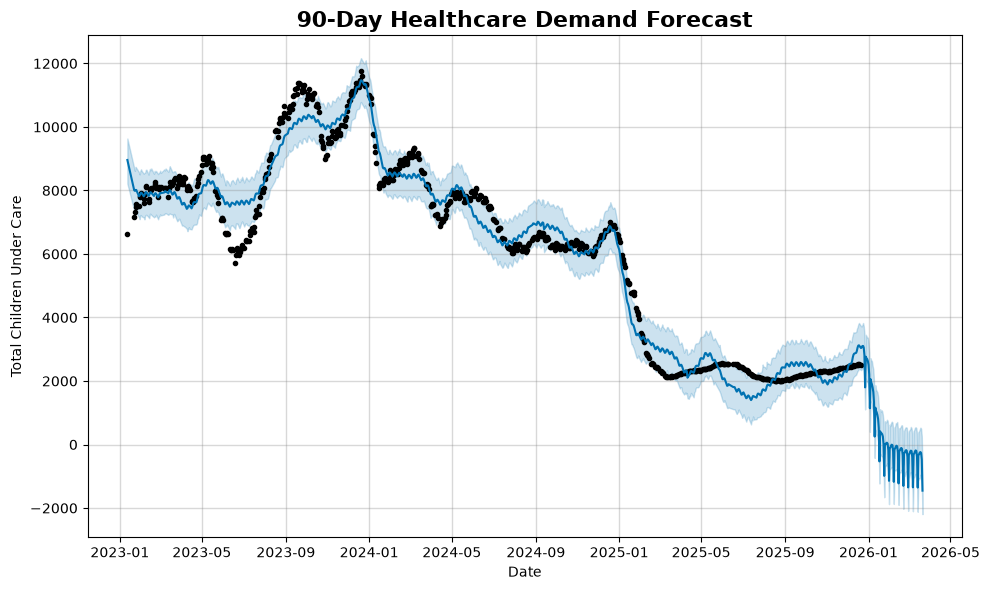

In [81]:
fig = prophet_model.plot(forecast)

plt.title(
    "90-Day Healthcare Demand Forecast",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Total Children Under Care")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Graphs/ml_02_prophet_forecast.png",
    dpi=300
)

plt.show()

### Interpretation

- Black dots represent historical observations.
- The blue line represents the forecast.
- The shaded region represents the confidence interval.
- This forecast supports healthcare capacity planning.

##  Trend and Seasonality Analysis

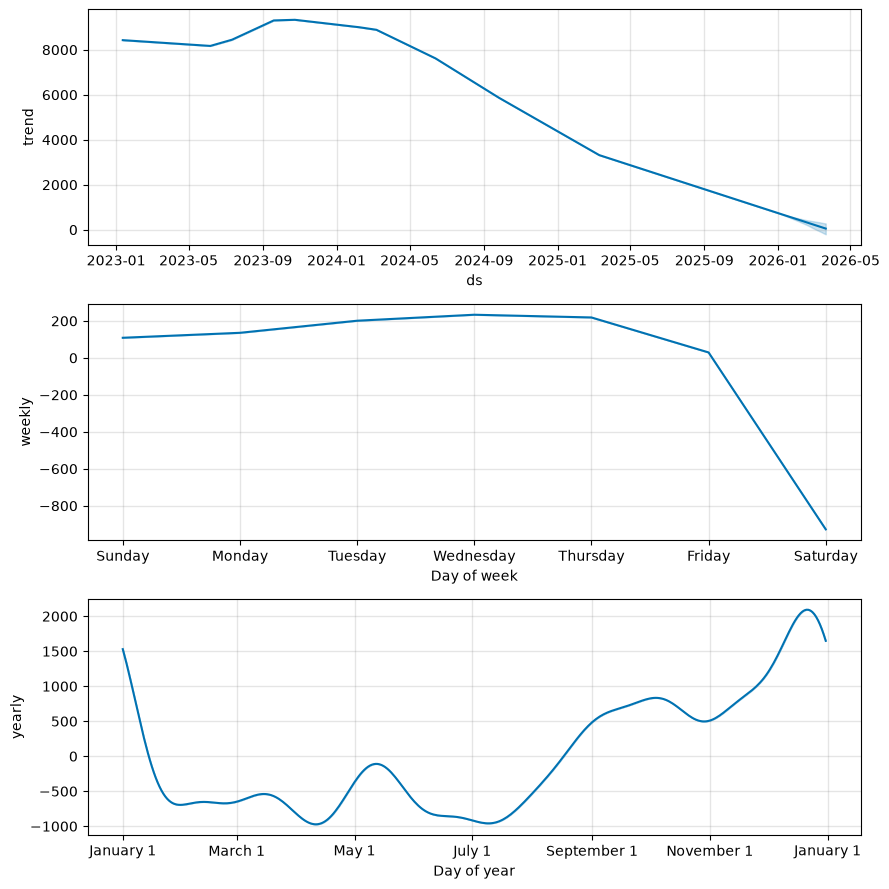

In [82]:
fig = prophet_model.plot_components(forecast)

plt.tight_layout()

plt.savefig(
    "Graphs/ml_03_prophet_components.png",
    dpi=300
)

plt.show()

### Interpretation

- Trend shows long-term healthcare demand.
- Weekly and yearly components identify recurring seasonal behavior.
- These patterns improve forecasting compared with Linear Regression.

### Save Forecast CSV

In [83]:
forecast[
    ["ds","yhat","yhat_lower","yhat_upper"]
].rename(
    columns={
        "ds":"Date",
        "yhat":"Forecast",
        "yhat_lower":"Lower CI",
        "yhat_upper":"Upper CI"
    }
).to_csv(
    "Outputs/forecast_90_days.csv",
    index=False
)

print("Forecast saved successfully.")

Forecast saved successfully.


### Save Cleaned Dataset

In [84]:
df.to_csv(
    "Outputs/cleaned_healthcare_data.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


### Save Prophet Model

In [85]:
import joblib

joblib.dump(
    prophet_model,
    "Models/prophet_forecast_model.pkl"
)

print("Prophet model saved successfully.")

Prophet model saved successfully.


### Freeze Project Libraries

In [86]:
import subprocess

with open("requirements.txt", "w") as f:
    subprocess.run(
        ["pip", "freeze"],
        stdout=f,
        check=True
    )

print("requirements.txt generated successfully.")

requirements.txt generated successfully.


------------------------------------------------------------------------
-------------------------------------------------------------------------

# Executive Summary

This project analyzes healthcare system capacity using daily operational data for Unaccompanied Children.

The objective is to understand historical workload trends, identify operational bottlenecks, measure capacity utilization, and forecast future healthcare demand.

The project combines:

- Data Cleaning
- Feature Engineering
- Exploratory Data Analysis
- Comparative Time Analysis
- Capacity & Load Pressure Analysis
- Machine Learning Forecasting
- Business Recommendations

The final deliverables support healthcare administrators in capacity planning, staffing decisions, and operational monitoring.

# Key Findings

- Healthcare demand showed significant fluctuations between 2023 and 2025.
- Daily volatility gradually declined, indicating improved operational stability.
- Capacity utilization remained consistently high throughout most of the study period.
- Peak demand occurred during late 2023 and early 2024.
- Transfer activity closely influenced overall system load.
- Comparative yearly analysis revealed a gradual reduction in average healthcare demand during 2025.
- Prophet forecasting predicts relatively stable healthcare demand over the next 90 days.

# Business Recommendations

- Increase staffing during historically high-demand periods.
- Continuously monitor Net Intake Pressure for early detection of capacity stress.
- Expand HHS placement capacity during seasonal demand peaks.
- Improve transfer efficiency to reduce backlog accumulation.
- Use forecast results for proactive resource allocation and operational planning.
- Develop automated dashboards for real-time monitoring.

# Limitations

- The analysis is based on historical operational data only.
- External factors such as policy changes, emergencies, or funding variations were not included.
- Linear Regression cannot model complex nonlinear relationships.
- Prophet assumes future trends follow historical patterns.
- Forecast accuracy depends on future operational consistency.

# Future Scope

Future improvements may include:

- XGBoost Regression
- Random Forest Regression
- LSTM Deep Learning Forecasting
- Real-time data integration
- Automated Power BI Dashboard
- Snowflake Data Warehouse Integration
- Cloud deployment using Azure or AWS
- Interactive Streamlit dashboard

# Conclusion

This project successfully analyzed healthcare system capacity and operational workload using historical healthcare data.

Exploratory analysis identified demand trends, capacity utilization, operational efficiency, and backlog patterns.

Comparative analysis highlighted long-term operational improvements, while forecasting models estimated future healthcare demand to support planning.

The project demonstrates a complete end-to-end Data Science workflow, including data preprocessing, exploratory analysis, predictive modeling, visualization, and actionable business recommendations.

The generated insights can assist healthcare administrators in improving resource allocation, operational efficiency, and long-term capacity planning.

-----------------------------------------------------------------------------------------
******************************************************************************************
------------------------------------------------------------------------------------------